# Pseudo-Random Number Generation: Mersenne Twister & Box-Muller Transform

This notebook explores two foundational topics in simulation and numerical methods:

1. **Mersenne Twister (MT19937)**: A widely-used pseudo-random number generator (PRNG)
2. **Box-Muller Transform**: A method to generate normally distributed random numbers from uniform random numbers

We implement both from scratch and visualize their properties using only **matplotlib** and **numpy**.


In [38]:
import numpy as np
import matplotlib.pyplot as plt

# Global settings
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
np.random.seed(42)


## 1. Mersenne Twister (MT19937)

The Mersenne Twister is a pseudo-random number generator developed by Makoto Matsumoto and Takuji Nishimura in 1997. It powers Python's legacy `random` module and NumPy's `RandomState`.

### Key Properties
- **Period**: $2^{19937} - 1$ (a Mersenne prime)
- **State size**: 624 words of 32 bits
- **Equidistribution**: 623-dimensional equidistribution
- **Speed**: Faster than many cryptographic generators

### Algorithm Overview
MT19937 maintains an internal state vector of 624 integers. It uses:
1. **Initialization**: A seed expands into the full state via a recurrence
2. **Twisting**: A linear feedback shift register (LFSR) style update
3. **Tempering**: Bit-masking operations to improve statistical properties

> **Modern Note**: NumPy's `Generator` (default since v1.17) uses **PCG64**, while `RandomState` still provides MT19937.


In [39]:
class MT19937:
    """
    Mersenne Twister MT19937 implementation.
    Generates 32-bit pseudo-random integers with period 2^19937 - 1.
    """
    def __init__(self, seed=5489):
        # MT19937 parameters
        self.w = 32
        self.n = 624
        self.m = 397
        self.r = 31
        self.a = 0x9908B0DF
        self.u = 11
        self.s = 7
        self.b = 0x9D2C5680
        self.t = 15
        self.c = 0xEFC60000
        self.ll = 18  # tempering shift (renamed to avoid any escape issues)
        self.f = 1812433253
        
        self.MT = [0] * self.n
        self.index = self.n + 1
        self.lower_mask = (1 << self.r) - 1
        self.upper_mask = (~self.lower_mask) & 0xFFFFFFFF
        
        self.seed_mt(seed)
    
    def seed_mt(self, seed):
        self.index = self.n
        self.MT[0] = seed & 0xFFFFFFFF
        for i in range(1, self.n):
            prev = self.MT[i - 1]
            self.MT[i] = (self.f * (prev ^ (prev >> (self.w - 2))) + i) & 0xFFFFFFFF
    
    def twist(self):
        for i in range(self.n):
            x = ((self.MT[i] & self.upper_mask) + 
                 (self.MT[(i + 1) % self.n] & self.lower_mask)) & 0xFFFFFFFF
            xA = x >> 1
            if (x & 1) != 0:
                xA = xA ^ self.a
            self.MT[i] = self.MT[(i + self.m) % self.n] ^ xA
        self.index = 0
    
    def temper(self, y):
        y = y ^ (y >> self.u)
        y = y ^ ((y << self.s) & self.b)
        y = y ^ ((y << self.t) & self.c)
        y = y ^ (y >> self.ll)
        return y & 0xFFFFFFFF
    
    def extract_number(self):
        if self.index >= self.n:
            if self.index > self.n:
                raise Exception("Generator was never seeded")
            self.twist()
        y = self.MT[self.index]
        y = self.temper(y)
        self.index += 1
        return y
    
    def random(self):
        """Return float in [0, 1)."""
        return self.extract_number() / (1 << self.w)
    
    def random_pair(self):
        """Return two consecutive random numbers."""
        return self.random(), self.random()


## Visualizing MT19937 Properties

We compare our from-scratch implementation against NumPy's `RandomState` (which also uses MT19937). We check:

- **Uniformity**: Histogram should be flat on [0, 1)
- **2D equidistribution**: Consecutive pairs should fill the unit square uniformly
- **Bit patterns**: Visual inspection of output bits for randomness
- **Time series**: No obvious trends or cycles in short windows
- 

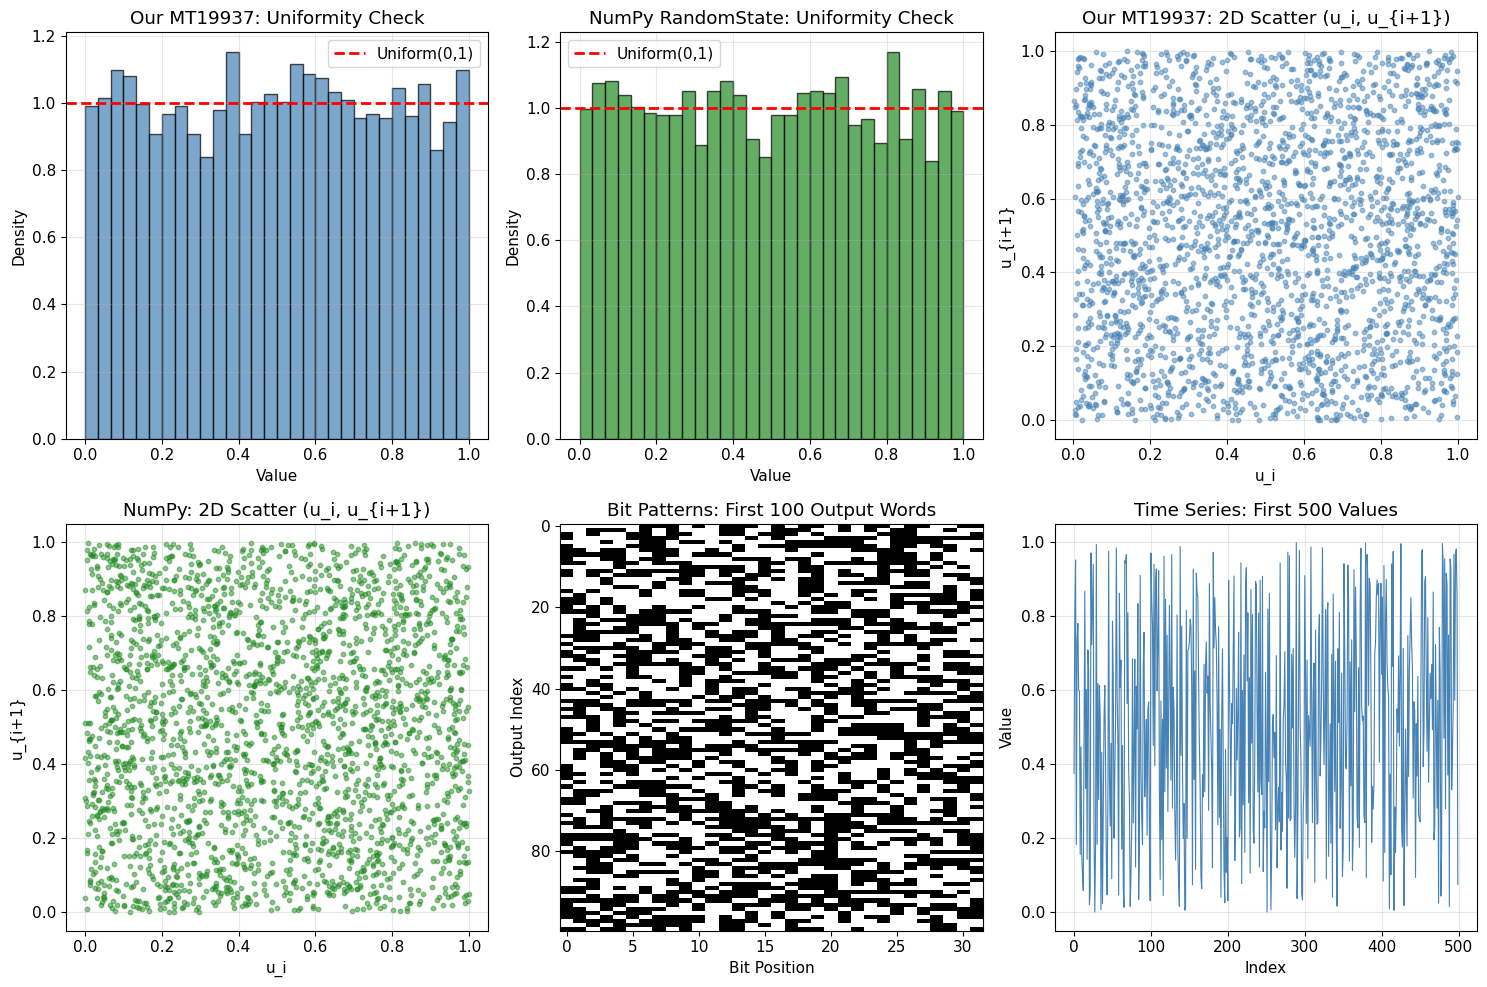

Chi-square statistic (uniformity): 16.1760
Degrees of freedom: 19
Mean: 0.499783, Std: 0.288373


In [40]:
# Initialize generators
mt = MT19937(seed=42)
np_mt = np.random.RandomState(42)  # NumPy's MT19937

n_samples = 5000
our_samples = np.array([mt.random() for _ in range(n_samples)])
np_samples = np_mt.rand(n_samples)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1D Histogram - Our MT19937
axes[0, 0].hist(our_samples, bins=30, density=True, alpha=0.7, color='steelblue', edgecolor='black')
axes[0, 0].axhline(1.0, color='red', linestyle='--', lw=2, label='Uniform(0,1)')
axes[0, 0].set_title('Our MT19937: Uniformity Check')
axes[0, 0].set_xlabel('Value')
axes[0, 0].set_ylabel('Density')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 1D Histogram - NumPy MT19937
axes[0, 1].hist(np_samples, bins=30, density=True, alpha=0.7, color='forestgreen', edgecolor='black')
axes[0, 1].axhline(1.0, color='red', linestyle='--', lw=2, label='Uniform(0,1)')
axes[0, 1].set_title('NumPy RandomState: Uniformity Check')
axes[0, 1].set_xlabel('Value')
axes[0, 1].set_ylabel('Density')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 2D Scatter - Our MT19937 (consecutive pairs)
axes[0, 2].scatter(our_samples[:-1:2], our_samples[1::2], alpha=0.5, s=10, color='steelblue')
axes[0, 2].set_title('Our MT19937: 2D Scatter (u_i, u_{i+1})')
axes[0, 2].set_xlabel('u_i')
axes[0, 2].set_ylabel('u_{i+1}')
axes[0, 2].grid(True, alpha=0.3)

# 2D Scatter - NumPy MT19937
axes[1, 0].scatter(np_samples[:-1:2], np_samples[1::2], alpha=0.5, s=10, color='forestgreen')
axes[1, 0].set_title('NumPy: 2D Scatter (u_i, u_{i+1})')
axes[1, 0].set_xlabel('u_i')
axes[1, 0].set_ylabel('u_{i+1}')
axes[1, 0].grid(True, alpha=0.3)

# Bit pattern visualization (first 100 numbers from fresh generator)
mt_bits = MT19937(seed=999)
bit_matrix = np.zeros((100, 32))
for i in range(100):
    val = mt_bits.extract_number()
    for j in range(32):
        bit_matrix[i, j] = (val >> j) & 1

axes[1, 1].imshow(bit_matrix, cmap='Greys', aspect='auto', interpolation='nearest')
axes[1, 1].set_title('Bit Patterns: First 100 Output Words')
axes[1, 1].set_xlabel('Bit Position')
axes[1, 1].set_ylabel('Output Index')

# Time series
axes[1, 2].plot(our_samples[:500], color='steelblue', lw=0.8)
axes[1, 2].set_title('Time Series: First 500 Values')
axes[1, 2].set_xlabel('Index')
axes[1, 2].set_ylabel('Value')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical test: Chi-square uniformity
bins = 20
observed, _ = np.histogram(our_samples, bins=bins)
expected = n_samples / bins
chi2_stat = np.sum((observed - expected)**2 / expected)
print(f"Chi-square statistic (uniformity): {chi2_stat:.4f}")
print(f"Degrees of freedom: {bins - 1}")
print(f"Mean: {np.mean(our_samples):.6f}, Std: {np.std(our_samples):.6f}")


## 2. Box-Muller Transform

The Box-Muller transform generates two independent standard normal variables from two independent uniform variables.

### Basic Form
Given $U_1, U_2 \sim \text{Uniform}(0, 1)$:

$$Z_0 = \sqrt{-2 \ln U_1} \cdot \cos(2\pi U_2)$$
$$Z_1 = \sqrt{-2 \ln U_1} \cdot \sin(2\pi U_2)$$

Then $Z_0, Z_1 \sim \mathcal{N}(0, 1)$ independently.

### Polar Form (Marsaglia)
A more efficient variant avoids trigonometric functions by rejection sampling inside the unit circle:

1. Generate $V_1, V_2 \sim \text{Uniform}(-1, 1)$ until $S = V_1^2 + V_2^2 < 1$
2. Compute:
   $$Z_0 = V_1 \cdot \sqrt{\frac{-2 \ln S}{S}}, \quad Z_1 = V_2 \cdot \sqrt{\frac{-2 \ln S}{S}}$$

**Rejection rate**: Approximately $1 - \pi/4 \approx 21.46\%$ of pairs are rejected.


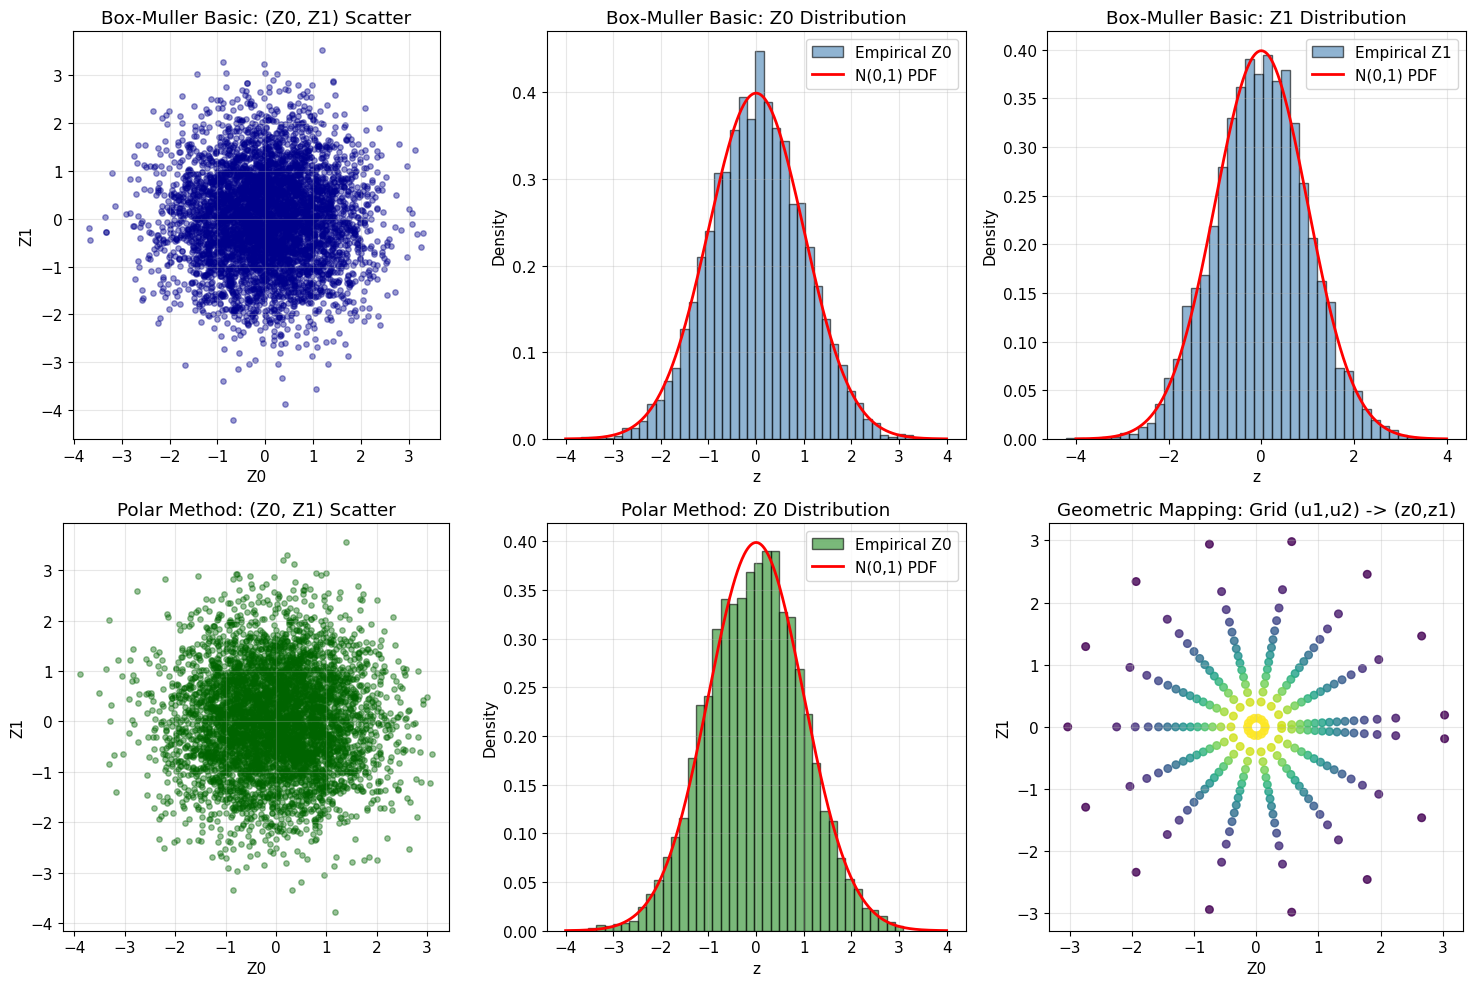

Box-Muller Basic - Mean Z0: 0.0169, Std Z0: 0.9881
Box-Muller Basic - Mean Z1: 0.0012, Std Z1: 1.0010
Polar Method     - Mean Z0: -0.0245, Std Z0: 1.0063
Rejection rate   : 0.2196 (theoretical: 0.2146)


In [41]:
def box_muller_basic(u1, u2):
    """Basic Box-Muller: two independent N(0,1) from two independent U(0,1)."""
    # Guard against log(0)
    u1 = np.where(u1 <= 0, 1e-10, u1)
    u2 = np.where(u2 <= 0, 1e-10, u2)
    r = np.sqrt(-2.0 * np.log(u1))
    theta = 2.0 * np.pi * u2
    z0 = r * np.cos(theta)
    z1 = r * np.sin(theta)
    return z0, z1

def box_muller_polar(u1, u2):
    """
    Marsaglia polar method.
    More efficient: no trig functions, but requires rejection.
    """
    v1 = 2.0 * u1 - 1.0
    v2 = 2.0 * u2 - 1.0
    s = v1**2 + v2**2
    # Keep only points inside unit circle, excluding origin
    mask = (s > 0) & (s < 1)
    v1, v2, s = v1[mask], v2[mask], s[mask]
    mult = np.sqrt(-2.0 * np.log(s) / s)
    z0 = v1 * mult
    z1 = v2 * mult
    return z0, z1

# Generate uniforms from our MT19937
mt_bm = MT19937(seed=12345)
n_requested = 5000

# Basic method: exact number of pairs
u1_basic = np.array([mt_bm.random() for _ in range(n_requested)])
u2_basic = np.array([mt_bm.random() for _ in range(n_requested)])
z0_basic, z1_basic = box_muller_basic(u1_basic, u2_basic)

# Polar method: generate extra to account for ~21.46% rejection
n_extra = int(n_requested * 1.35)
u1_polar = np.array([mt_bm.random() for _ in range(n_extra)])
u2_polar = np.array([mt_bm.random() for _ in range(n_extra)])
z0_polar_all, z1_polar_all = box_muller_polar(u1_polar, u2_polar)
z0_polar = z0_polar_all[:n_requested]
z1_polar = z1_polar_all[:n_requested]

# Theoretical normal PDF
x_norm = np.linspace(-4, 4, 500)
pdf_norm = (1.0 / np.sqrt(2.0 * np.pi)) * np.exp(-0.5 * x_norm**2)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Basic Box-Muller: Scatter
axes[0, 0].scatter(z0_basic, z1_basic, alpha=0.4, s=15, color='darkblue')
axes[0, 0].set_title('Box-Muller Basic: (Z0, Z1) Scatter')
axes[0, 0].set_xlabel('Z0')
axes[0, 0].set_ylabel('Z1')
axes[0, 0].set_aspect('equal')
axes[0, 0].grid(True, alpha=0.3)

# Basic Box-Muller: Z0 Histogram
axes[0, 1].hist(z0_basic, bins=40, density=True, alpha=0.6, color='steelblue', edgecolor='black', label='Empirical Z0')
axes[0, 1].plot(x_norm, pdf_norm, 'r-', lw=2, label='N(0,1) PDF')
axes[0, 1].set_title('Box-Muller Basic: Z0 Distribution')
axes[0, 1].set_xlabel('z')
axes[0, 1].set_ylabel('Density')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Basic Box-Muller: Z1 Histogram
axes[0, 2].hist(z1_basic, bins=40, density=True, alpha=0.6, color='steelblue', edgecolor='black', label='Empirical Z1')
axes[0, 2].plot(x_norm, pdf_norm, 'r-', lw=2, label='N(0,1) PDF')
axes[0, 2].set_title('Box-Muller Basic: Z1 Distribution')
axes[0, 2].set_xlabel('z')
axes[0, 2].set_ylabel('Density')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Polar Box-Muller: Scatter
axes[1, 0].scatter(z0_polar, z1_polar, alpha=0.4, s=15, color='darkgreen')
axes[1, 0].set_title('Polar Method: (Z0, Z1) Scatter')
axes[1, 0].set_xlabel('Z0')
axes[1, 0].set_ylabel('Z1')
axes[1, 0].set_aspect('equal')
axes[1, 0].grid(True, alpha=0.3)

# Polar Box-Muller: Z0 Histogram
axes[1, 1].hist(z0_polar, bins=40, density=True, alpha=0.6, color='forestgreen', edgecolor='black', label='Empirical Z0')
axes[1, 1].plot(x_norm, pdf_norm, 'r-', lw=2, label='N(0,1) PDF')
axes[1, 1].set_title('Polar Method: Z0 Distribution')
axes[1, 1].set_xlabel('z')
axes[1, 1].set_ylabel('Density')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Geometric interpretation: grid in (u1, u2) mapped to (z0, z1)
grid_u = np.linspace(0.01, 0.99, 15)
U1, U2 = np.meshgrid(grid_u, grid_u)
R = np.sqrt(-2.0 * np.log(U1))
Theta = 2.0 * np.pi * U2
Z0_grid = R * np.cos(Theta)
Z1_grid = R * np.sin(Theta)

axes[1, 2].scatter(Z0_grid.flatten(), Z1_grid.flatten(), c=U1.flatten(), cmap='viridis', s=30, alpha=0.8)
axes[1, 2].set_title('Geometric Mapping: Grid (u1,u2) -> (z0,z1)')
axes[1, 2].set_xlabel('Z0')
axes[1, 2].set_ylabel('Z1')
axes[1, 2].set_aspect('equal')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Box-Muller Basic - Mean Z0: {np.mean(z0_basic):.4f}, Std Z0: {np.std(z0_basic):.4f}")
print(f"Box-Muller Basic - Mean Z1: {np.mean(z1_basic):.4f}, Std Z1: {np.std(z1_basic):.4f}")
print(f"Polar Method     - Mean Z0: {np.mean(z0_polar):.4f}, Std Z0: {np.std(z0_polar):.4f}")
print(f"Rejection rate   : {1 - len(z0_polar_all)/n_extra:.4f} (theoretical: {1 - np.pi/4:.4f})")


## 3. Method Comparison & Statistical Properties

We now compare the empirical cumulative distribution functions (CDFs) and analyze the correlation structure of both the uniform PRNG and the resulting normal variates.

Key checks:
- **Empirical CDF**: Should closely match the theoretical normal CDF $\Phi(z)$
- **Lag-1 plot**: Should show no structure (independence)
- **Autocorrelation**: Should be near zero for all lags > 0

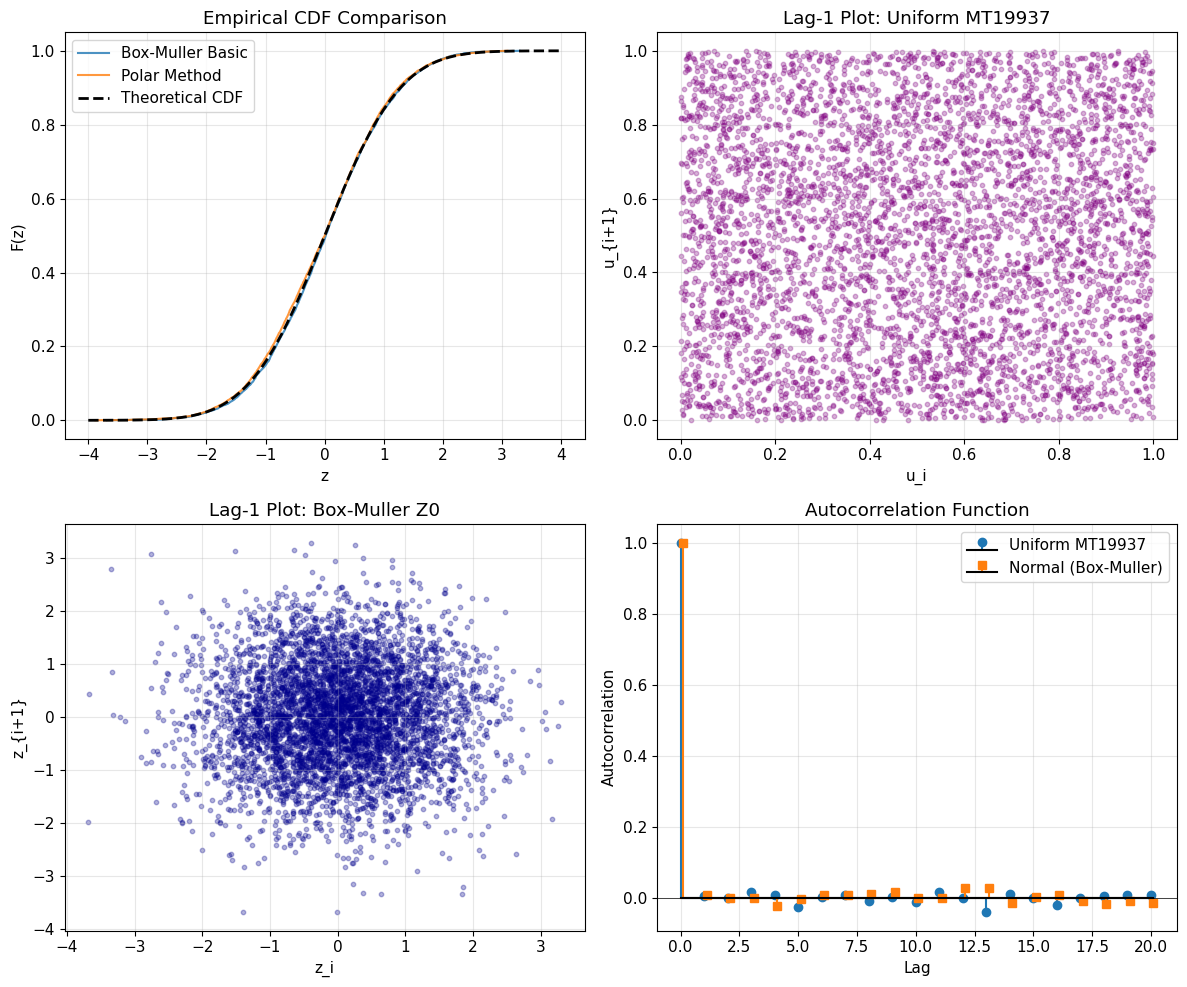

Max |F_empirical - F_theoretical| for Z0: 0.0115
Lag-1 correlation (uniform): 0.005484
Lag-1 correlation (normal) : 0.007050


In [42]:
from math import erf

def empirical_cdf(data):
    sorted_data = np.sort(data)
    cdf_vals = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    return sorted_data, cdf_vals

def autocorr(x, max_lags=20):
    x = x - np.mean(x)
    autocorrs = []
    for lag in range(max_lags + 1):
        if lag == 0:
            autocorrs.append(1.0)
        else:
            c = np.sum(x[:-lag] * x[lag:]) / np.sum(x**2)
            autocorrs.append(c)
    return np.array(autocorrs)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Empirical CDF comparison for Z0
x_emp_basic, y_emp_basic = empirical_cdf(z0_basic)
x_emp_polar, y_emp_polar = empirical_cdf(z0_polar)
theory_cdf_vals = np.array([0.5 * (1 + erf(val / np.sqrt(2))) for val in x_norm])

axes[0, 0].plot(x_emp_basic, y_emp_basic, lw=1.5, label='Box-Muller Basic', alpha=0.8)
axes[0, 0].plot(x_emp_polar, y_emp_polar, lw=1.5, label='Polar Method', alpha=0.8)
axes[0, 0].plot(x_norm, theory_cdf_vals, 'k--', lw=2, label='Theoretical CDF')
axes[0, 0].set_title('Empirical CDF Comparison')
axes[0, 0].set_xlabel('z')
axes[0, 0].set_ylabel('F(z)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Lag-1 plot for uniform PRNG
axes[0, 1].scatter(our_samples[:-1], our_samples[1:], alpha=0.3, s=10, color='purple')
axes[0, 1].set_title('Lag-1 Plot: Uniform MT19937')
axes[0, 1].set_xlabel('u_i')
axes[0, 1].set_ylabel('u_{i+1}')
axes[0, 1].grid(True, alpha=0.3)

# Lag-1 plot for normal
axes[1, 0].scatter(z0_basic[:-1], z0_basic[1:], alpha=0.3, s=10, color='darkblue')
axes[1, 0].set_title('Lag-1 Plot: Box-Muller Z0')
axes[1, 0].set_xlabel('z_i')
axes[1, 0].set_ylabel('z_{i+1}')
axes[1, 0].grid(True, alpha=0.3)

# Autocorrelation function
lags = np.arange(21)
ac_uniform = autocorr(our_samples, 20)
ac_normal = autocorr(z0_basic, 20)

axes[1, 1].stem(lags, ac_uniform, linefmt='C0-', markerfmt='C0o', basefmt='k-', label='Uniform MT19937')
axes[1, 1].stem(lags + 0.1, ac_normal, linefmt='C1-', markerfmt='C1s', basefmt='k-', label='Normal (Box-Muller)')
axes[1, 1].axhline(0, color='black', linestyle='-', lw=0.5)
axes[1, 1].set_title('Autocorrelation Function')
axes[1, 1].set_xlabel('Lag')
axes[1, 1].set_ylabel('Autocorrelation')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Kolmogorov-Smirnov-like max deviation for basic method
n = len(z0_basic)
sorted_z = np.sort(z0_basic)
empirical = np.arange(1, n + 1) / n
theoretical_at_samples = np.array([0.5 * (1 + erf(val / np.sqrt(2))) for val in sorted_z])
ks_like = np.max(np.abs(empirical - theoretical_at_samples))
print(f"Max |F_empirical - F_theoretical| for Z0: {ks_like:.4f}")
print(f"Lag-1 correlation (uniform): {np.corrcoef(our_samples[:-1], our_samples[1:])[0,1]:.6f}")
print(f"Lag-1 correlation (normal) : {np.corrcoef(z0_basic[:-1], z0_basic[1:])[0,1]:.6f}")


## 4. Summary and Key Takeaways

### Mersenne Twister
- **Strengths**: Huge period ($2^{19937}-1$), fast, well-tested, good equidistribution
- **Weaknesses**: Not cryptographically secure (state can be inferred from outputs)
- **Modern replacement**: NumPy's `default_rng()` uses **PCG64**, which has better statistical properties and is faster

### Box-Muller Transform
- **Basic form**: Elegant, exact, requires trigonometric functions
- **Polar form**: ~30% faster in practice (no trig), but requires rejection sampling (~21.5% rejection)
- **Key insight**: Maps uniform randomness on the unit square to radial symmetry in the normal plane via $R = \sqrt{-2\ln U_1}$ and $\Theta = 2\pi U_2$

### Practical Notes for Simulation
1. **Never use pure `random.random()` for serious Monte Carlo** without understanding the underlying PRNG
2. **Seed management matters**: For reproducible simulations, always set seeds explicitly
3. **Normal generation**: If speed is critical, use the polar method or `numpy.random.Generator.standard_normal()` (which uses the Ziggurat algorithm)
4. **Period awareness**: For $> 10^{600}$ samples, MT19937 would theoretically repeat; in practice, you will never exhaust it